In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df= pd.read_csv("/content/TELCOCUSTOMERCHURN.csv")

df.shape
df.head(6)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes


In [3]:
df['Contract'].value_counts()  #ye btaega har contract mai kitne customers hai


,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [4]:
df.groupby(['Contract','Churn']).size()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
dtype: int64

In [5]:
churn_rate=pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize="index"
)*100

print(churn_rate)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


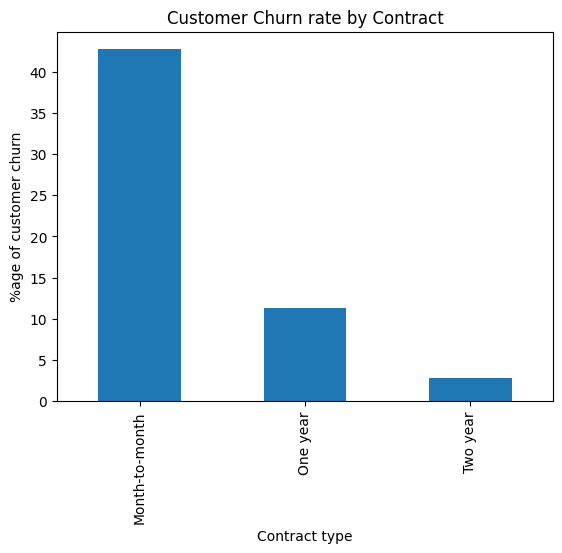

In [6]:
churn_rate['Yes'].plot(kind='bar')
plt.title("Customer Churn rate by Contract")
plt.xlabel('Contract type')
plt.ylabel('%age of customer churn')
plt.show()


In [7]:
df.groupby(['tenure','Churn']).size()

tenure  Churn
0       No        11
1       No       233
        Yes      380
2       No       115
        Yes      123
                ... 
70      Yes       11
71      No       164
        Yes        6
72      No       356
        Yes        6
Length: 145, dtype: int64

Churn           No        Yes
tenure                       
0       100.000000   0.000000
1        38.009788  61.990212
2        48.319328  51.680672
3        53.000000  47.000000
4        52.840909  47.159091
...            ...        ...
68       91.000000   9.000000
69       91.578947   8.421053
70       90.756303   9.243697
71       96.470588   3.529412
72       98.342541   1.657459

[73 rows x 2 columns]


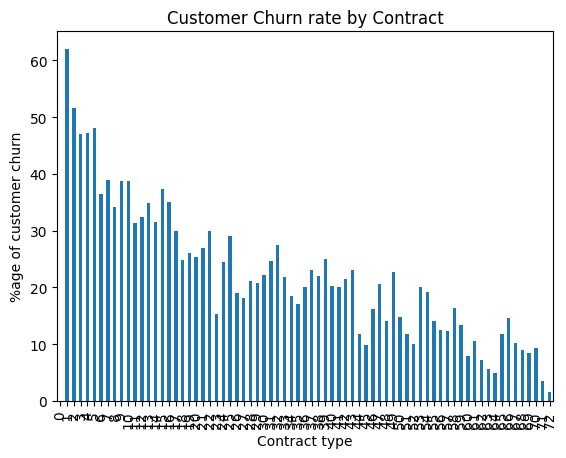

In [8]:
churn_rate1=pd.crosstab(
    df['tenure'],
    df['Churn'],
    normalize="index"
)*100

print(churn_rate1)

churn_rate1['Yes'].plot(kind='bar')
plt.title("Customer Churn rate by Contract")
plt.xlabel('Contract type')
plt.ylabel('%age of customer churn')
plt.show()



In [9]:
df.groupby(['MonthlyCharges','Churn']).describe()

SeniorCitizen                                    tenure  \
                             count mean  std  min  25%  50%  75%  max  count   
MonthlyCharges Churn                                                           
18.25          No              1.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0    1.0   
18.40          No              1.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0    1.0   
18.55          No              1.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0    1.0   
18.70          No              2.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0    2.0   
18.75          No              1.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0    1.0   
...                            ...  ...  ...  ...  ...  ...  ...  ...    ...   
118.20         No              1.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0    1.0   
118.35         Yes             1.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0    1.0   
118.60         No              2.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0    2.0   
118.65         No              1.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0    1.0   
118.75         No              1.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0    1.0   

                                                                       
                      mean        std   min    25%   50%    75%   max  
MonthlyCharges Churn                                                   
18.25          No     28.0        NaN  28.0  28.00  28.0  28.00  28.0  
18.40          No     59.0        NaN  59.0  59.00  59.0  59.00  59.0  
18.55          No     36.0        NaN  36.0  36.00  36.0  36.00  36.0  
18.70          No     39.0  19.798990  25.0  32.00  39.0  46.00  53.0  
18.75          No      2.0        NaN   2.0   2.00   2.0   2.00   2.0  
...                    ...        ...   ...    ...   ...    ...   ...  
118.20         No     72.0        NaN  72.0  72.00  72.0  72.00  72.0  
118.35         Yes    67.0        NaN  67.0  67.00  67.0  67.00  67.0  
118.60         No     64.5   4.949747  61.0  62.75  64.5  66.25  68.0  
118.65         No     71.0        NaN  71.0  71.00  71.0  71.00  71.0  
118.75         No     72.0        NaN  72.0  72.00  72.0  72.00  72.0  

[2370 rows x 16 columns]

Churn              No    Yes
MonthlyCharges              
18.25           100.0    0.0
18.40           100.0    0.0
18.55           100.0    0.0
18.70           100.0    0.0
18.75           100.0    0.0
...               ...    ...
118.20          100.0    0.0
118.35            0.0  100.0
118.60          100.0    0.0
118.65          100.0    0.0
118.75          100.0    0.0

[1585 rows x 2 columns]


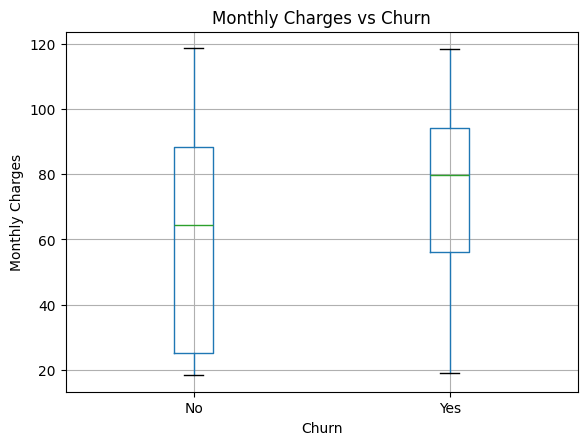

In [10]:
churnrate2=pd.crosstab(
    df['MonthlyCharges'],
    df['Churn'],
    normalize="index"
)*100

print(churnrate2)


df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [11]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


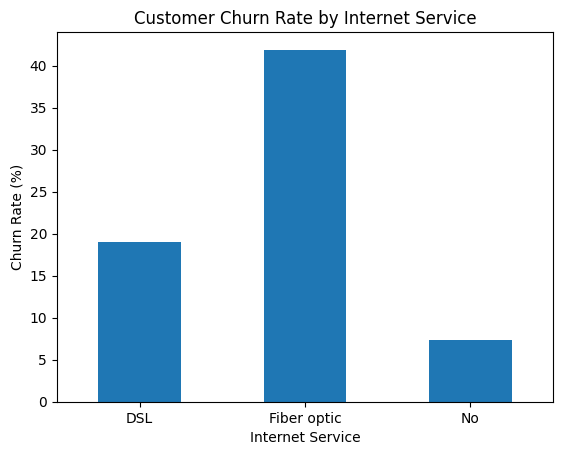

In [12]:
internet_churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

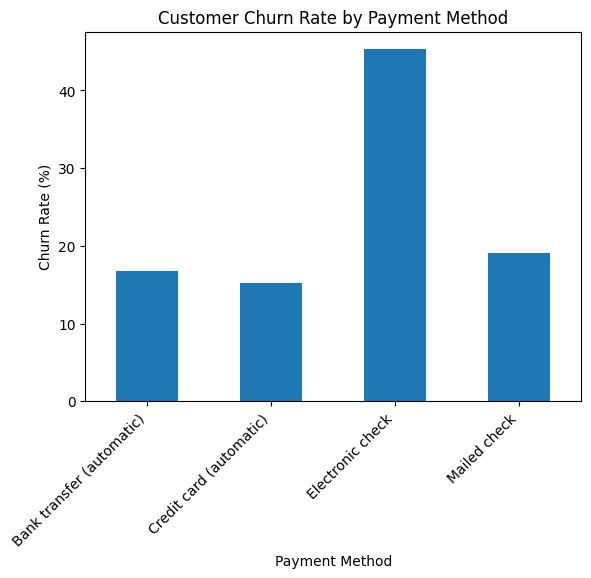

In [13]:
payment_churn=pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize="index"
)*100

payment_churn["Yes"].plot(kind="bar")

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()



In [14]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df.info())
print(df["TotalCharges"].dtype)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 

In [15]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [16]:
df= df.drop("customerID",axis=1)

In [17]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
df["TotalCharges"].dtype

dtype('O')

In [19]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [20]:
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isnull().sum())

float64
11


In [21]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes": 1, "No": 0})

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
X_train.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(
    include=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

#Decision tree starts from here

In [26]:
#Decision tree starts from here

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

EVALUATION

In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.71611071682044
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1035
           1       0.47      0.48      0.47       374

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409



RANDOM FOREST FROM HERE

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [29]:
y_pred_rf = rf_model.predict(X_test)

EVALUATION

In [30]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7835344215755855
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



BOTH MODELS ACCURACY

In [31]:
print("Decision Tree:",
      accuracy_score(y_test, y_pred_dt))

print("Random Forest:",
      accuracy_score(y_test, y_pred_rf))

Decision Tree: 0.71611071682044
Random Forest: 0.7835344215755855


Confusion Matrix and Recall


[[924 111]
 [194 180]]


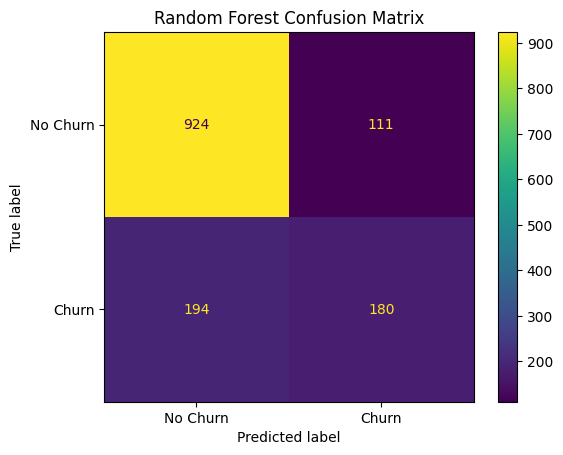

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



MODEL TUNING

In [34]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovie...
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                             ('model',
                                              RandomForestClassifier(n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1')

In [35]:
print(random_search.best_params_)

{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10}


In [36]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



FEATURE IMPORTANCE

In [37]:
feature_names = (
    best_rf
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [38]:
importances = (
    best_rf
    .named_steps["model"]
    .feature_importances_
)

In [39]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                                Feature  Importance
42                    remainder__tenure    0.140370
44              remainder__TotalCharges    0.122442
32         cat__Contract_Month-to-month    0.088388
43            remainder__MonthlyCharges    0.087388
14               cat__OnlineSecurity_No    0.057277
12     cat__InternetService_Fiber optic    0.045257
39  cat__PaymentMethod_Electronic check    0.045162
23                  cat__TechSupport_No    0.040707
34               cat__Contract_Two year    0.036080
11             cat__InternetService_DSL    0.021690
17                 cat__OnlineBackup_No    0.020311
16              cat__OnlineSecurity_Yes    0.018024
33               cat__Contract_One year    0.017326
35             cat__PaperlessBilling_No    0.013485
25                 cat__TechSupport_Yes    0.013382


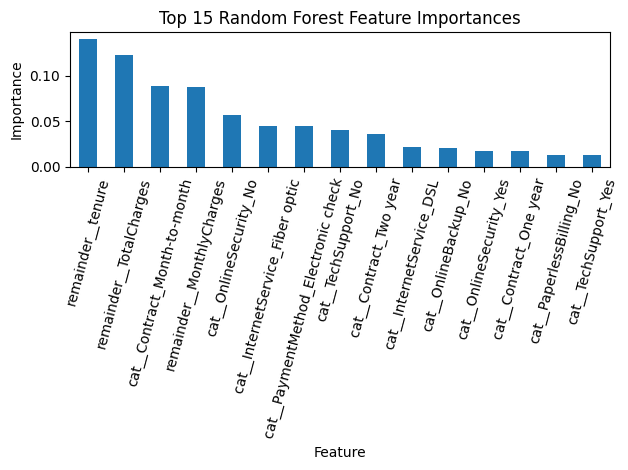

In [40]:
feature_importance.head(15).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

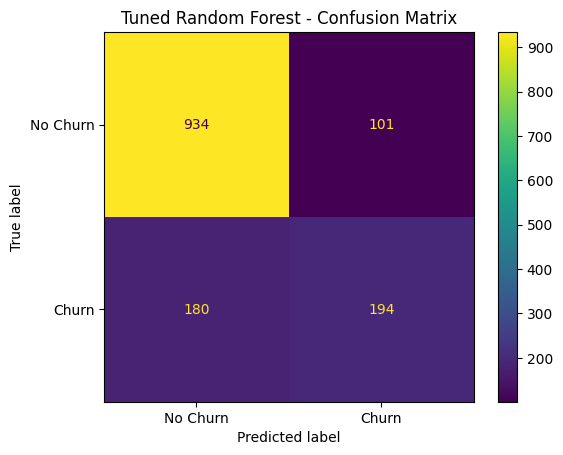

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=["No Churn", "Churn"]
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [42]:
import joblib

joblib.dump(
    best_rf,
    "random_forest_churn_model.pkl"
)

['random_forest_churn_model.pkl']

In [43]:
model = joblib.load(
    "random_forest_churn_model.pkl"
)

In [44]:
import os

print(os.path.exists("random_forest_churn_model.pkl"))

True


In [45]:
from sklearn.metrics import roc_auc_score

y_prob = best_rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.840074659639877
